# Histograms & Filtering
This notebook covers grayscale histogram analysis, histogram equalization, CLAHE, noise filtering, and manual convolution with Sobel filtering.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 100

def show_row(titles, imgs, cmaps=None, figsize=(16,4)):
    if cmaps is None:
        cmaps = [None] * len(imgs)
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1:
        axes = [axes]
    for ax, title, img, cmap in zip(axes, titles, imgs, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

base = os.path.join('images')


## 7. Strawberry histogram and exposure
Load strawberry.jpg as grayscale and plot its histogram. Inspect whether the image is well exposed and what the histogram shape says about contrast.


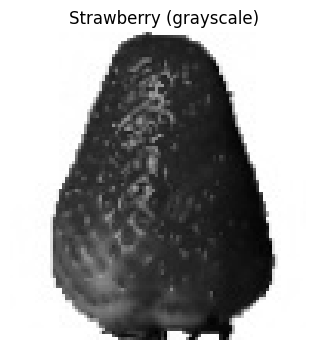

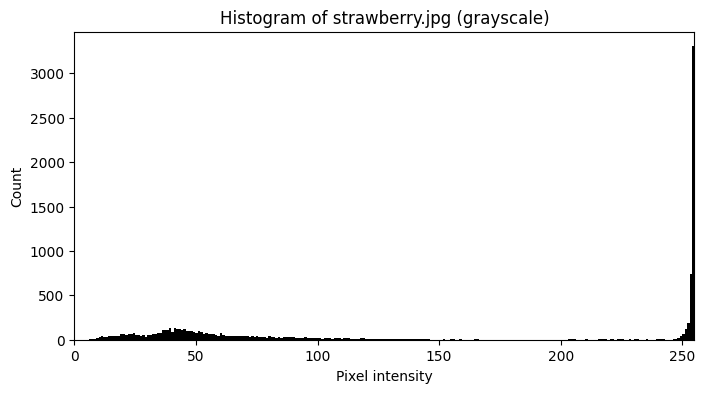

Mean intensity: 146.3, std: 101.7
A histogram concentrated in the midtones indicates moderate exposure and limited contrast; a wide spread suggests higher contrast.


In [2]:
straw = cv2.imread(os.path.join(base, 'strawberry.jpg'), cv2.IMREAD_GRAYSCALE)
if straw is None:
    raise FileNotFoundError('strawberry.jpg not found')

plt.figure(figsize=(6,4))
plt.imshow(straw, cmap='gray')
plt.title('Strawberry (grayscale)')
plt.axis('off')
plt.show()

plt.figure(figsize=(8,4))
plt.hist(straw.ravel(), bins=256, range=(0,255), color='black')
plt.title('Histogram of strawberry.jpg (grayscale)')
plt.xlabel('Pixel intensity')
plt.ylabel('Count')
plt.xlim([0,255])
plt.show()

mean_val = np.mean(straw)
std_val = np.std(straw)
print(f'Mean intensity: {mean_val:.1f}, std: {std_val:.1f}')
print('A histogram concentrated in the midtones indicates moderate exposure and limited contrast; a wide spread suggests higher contrast.')


## 8. Global histogram equalization and CLAHE
Apply global histogram equalization and CLAHE with clip limits 2.0 and 8.0, then compare the results.


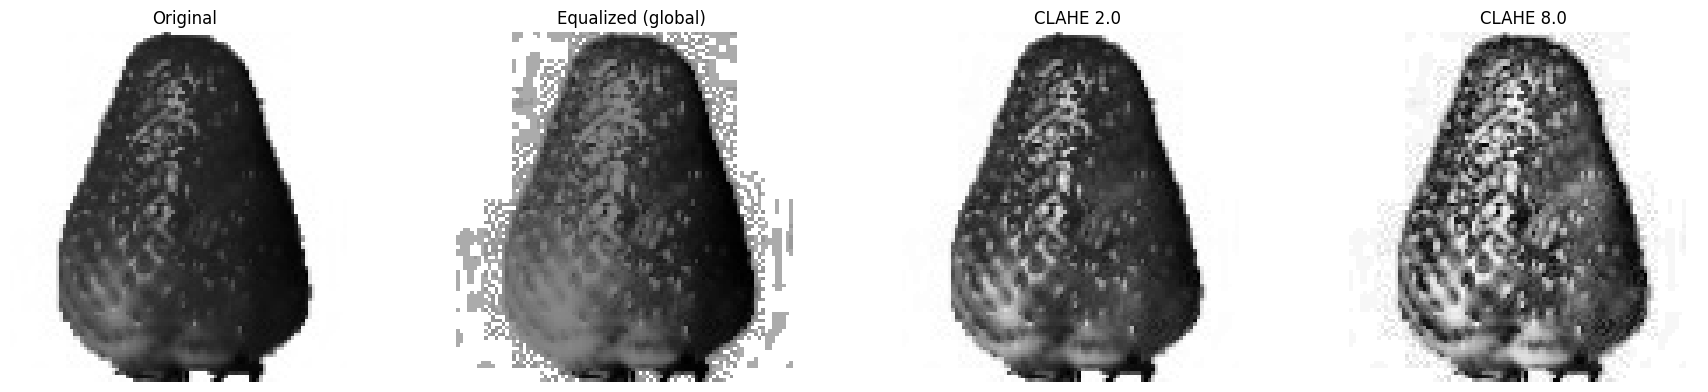

CLAHE with clipLimit=2.0 typically improves local contrast with fewer artifacts.
CLAHE with clipLimit=8.0 may over-amplify details and produce a harsher look.


In [3]:
equalized = cv2.equalizeHist(straw)
clahe2 = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(straw)
clahe8 = cv2.createCLAHE(clipLimit=8.0, tileGridSize=(8,8)).apply(straw)

show_row(
    ['Original', 'Equalized (global)', 'CLAHE 2.0', 'CLAHE 8.0'],
    [straw, equalized, clahe2, clahe8],
    ['gray'] * 4,
    figsize=(18,4)
)
print('CLAHE with clipLimit=2.0 typically improves local contrast with fewer artifacts.')
print('CLAHE with clipLimit=8.0 may over-amplify details and produce a harsher look.')


## 9. Noise experiment on orange.jpg
Add Gaussian noise to orange.jpg, then compare Gaussian blur, median filter, and bilateral filter.


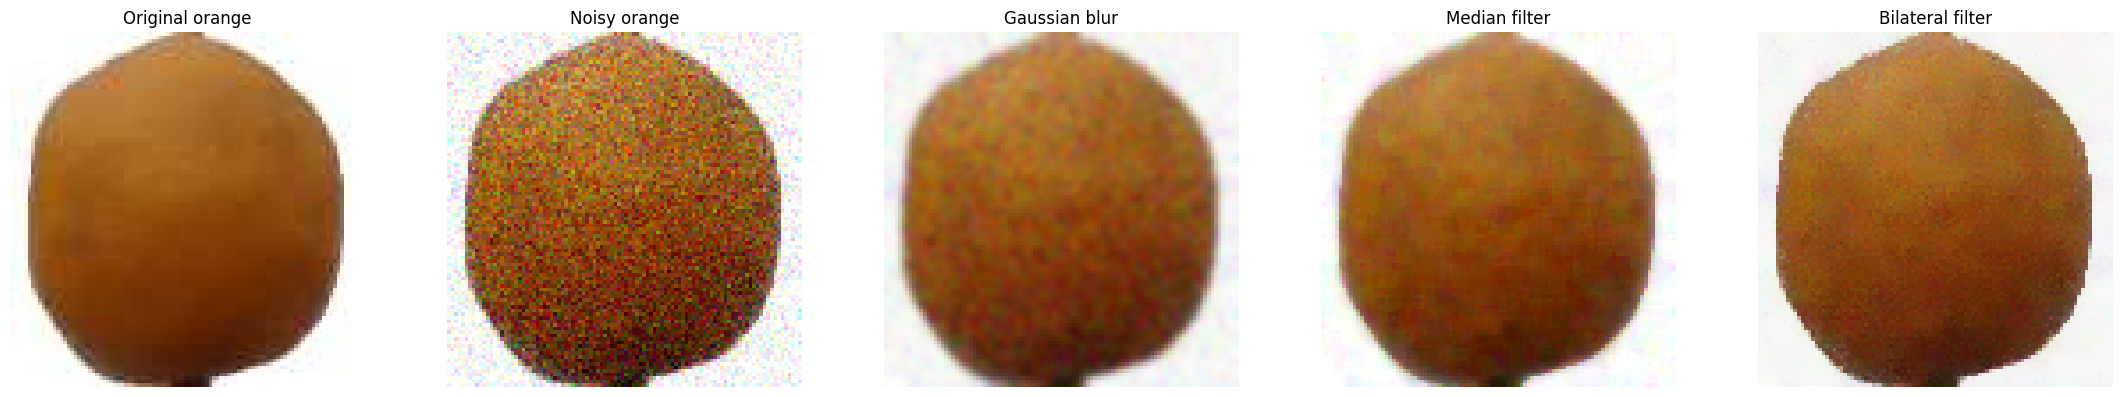

Median filter often removes noise while preserving edges better than Gaussian blur.
Bilateral filter keeps edges sharper but may leave some noise.


In [4]:
orange_bgr = cv2.imread(os.path.join(base, 'orange.jpg'))
if orange_bgr is None:
    raise FileNotFoundError('orange.jpg not found')
orange = cv2.cvtColor(orange_bgr, cv2.COLOR_BGR2RGB)

rng = np.random.default_rng(12345)
noise = rng.normal(0, 25, orange.shape).astype(np.float32)
noisy = np.clip(orange.astype(np.float32) + noise, 0, 255).astype(np.uint8)

gauss = cv2.GaussianBlur(noisy, (5,5), 0)
median = cv2.medianBlur(noisy, 5)
bilat = cv2.bilateralFilter(noisy, d=9, sigmaColor=75, sigmaSpace=75)

show_row(
    ['Original orange', 'Noisy orange', 'Gaussian blur', 'Median filter', 'Bilateral filter'],
    [orange, noisy, gauss, median, bilat],
    [None] * 5,
    figsize=(22,4)
)
print('Median filter often removes noise while preserving edges better than Gaussian blur.')
print('Bilateral filter keeps edges sharper but may leave some noise.')


## 10. Extended — manual convolution with Sobel X
Implement convolution from scratch and compare the result with cv2.filter2D.


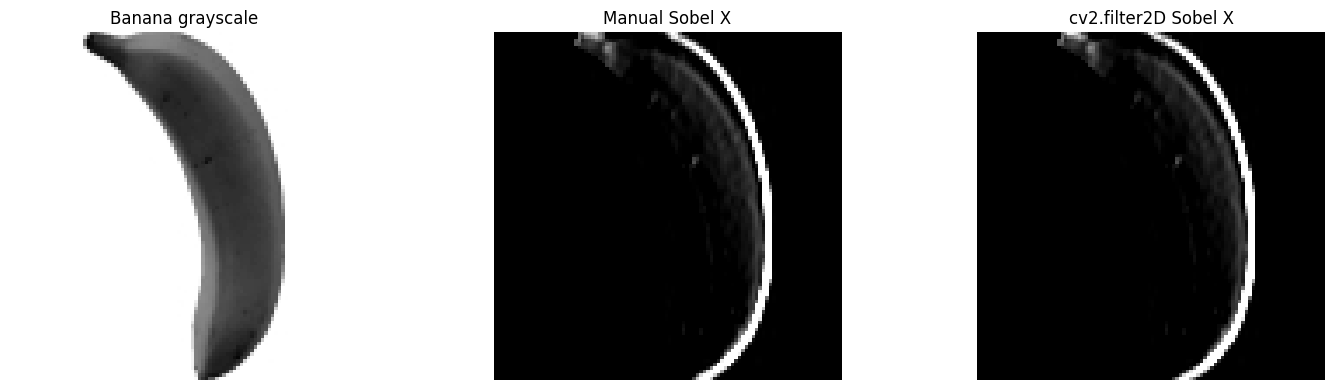

Mean absolute difference between manual convolution and cv2.filter2D: 0.1151
Any small discrepancy is likely due to border handling or dtype details.


In [5]:
def conv2d(image, kernel):
    image = image.astype(np.float32)
    kernel = kernel.astype(np.float32)
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    output = np.zeros_like(image, dtype=np.float32)
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            region = padded[y:y + kh, x:x + kw]
            output[y, x] = np.sum(region * kernel)
    return np.clip(output, 0, 255).astype(np.uint8)

banana = cv2.imread(os.path.join(base, 'banana.jpg'), cv2.IMREAD_GRAYSCALE)
if banana is None:
    raise FileNotFoundError('banana.jpg not found')
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)

manual_sobel = conv2d(banana, sobel_x)
cv_sobel = cv2.filter2D(banana, ddepth=-1, kernel=sobel_x, borderType=cv2.BORDER_REFLECT)

show_row(
    ['Banana grayscale', 'Manual Sobel X', 'cv2.filter2D Sobel X'],
    [banana, manual_sobel, cv_sobel],
    ['gray'] * 3,
    figsize=(15,4)
)
difference = np.mean(np.abs(manual_sobel.astype(np.float32) - cv_sobel.astype(np.float32)))
print(f'Mean absolute difference between manual convolution and cv2.filter2D: {difference:.4f}')
print('Any small discrepancy is likely due to border handling or dtype details.')


## Part C — Morphology & Mask Cleanup
A raw HSV mask is rarely clean. Apply erosion, opening, closing, gradient outline, examine direct BGR morphology, and demo j.png operations.


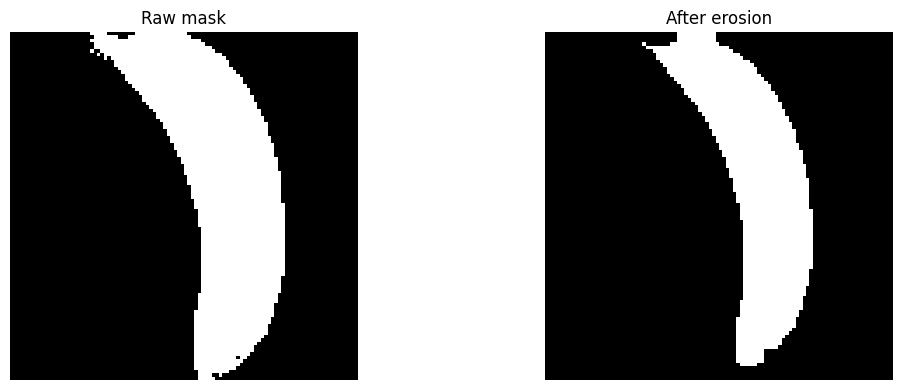

Erosion shrinks the mask and removes small spurious blobs, but it also removes thin banana boundaries.


In [6]:
banana_bgr = cv2.imread(os.path.join(base, 'banana.jpg'))
if banana_bgr is None:
    raise FileNotFoundError('banana.jpg not found')
banana_rgb = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2RGB)
banana_hsv = cv2.cvtColor(banana_bgr, cv2.COLOR_BGR2HSV)

lower_banana = np.array([10, 50, 50])
upper_banana = np.array([40, 255, 255])
raw_mask = cv2.inRange(banana_hsv, lower_banana, upper_banana)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
eroded_mask = cv2.erode(raw_mask, kernel, iterations=1)

show_row(
    ['Raw mask', 'After erosion'],
    [raw_mask, eroded_mask],
    ['gray', 'gray'],
    figsize=(12,4)
)
print('Erosion shrinks the mask and removes small spurious blobs, but it also removes thin banana boundaries.')


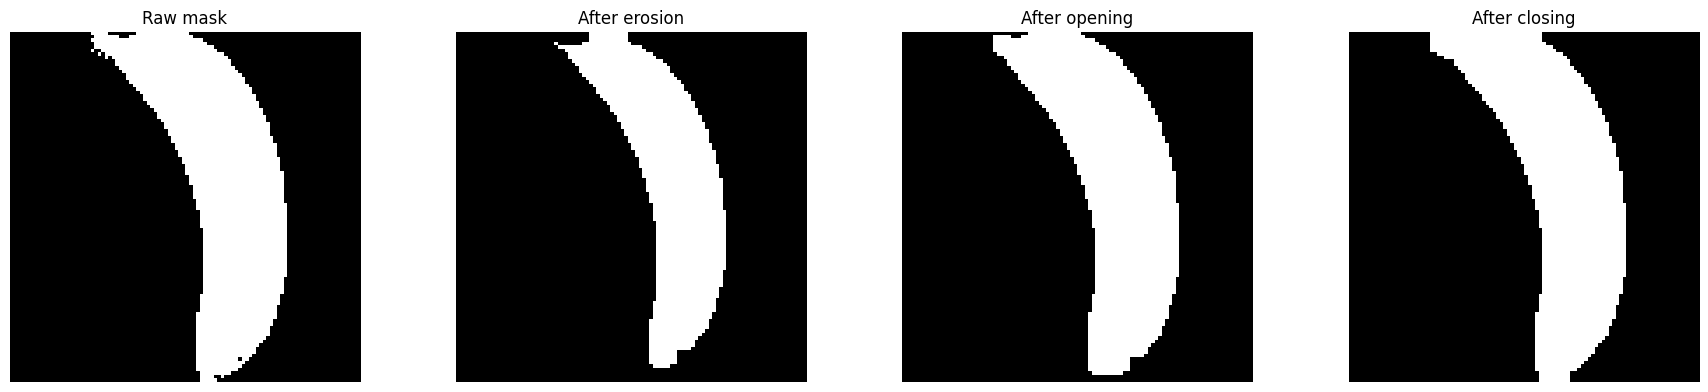

Opening removes isolated noise blobs; closing fills small holes and gaps in the banana mask.


In [7]:
opened_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
closed_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE, kernel)

show_row(
    ['Raw mask', 'After erosion', 'After opening', 'After closing'],
    [raw_mask, eroded_mask, opened_mask, closed_mask],
    ['gray'] * 4,
    figsize=(18,4)
)
print('Opening removes isolated noise blobs; closing fills small holes and gaps in the banana mask.')


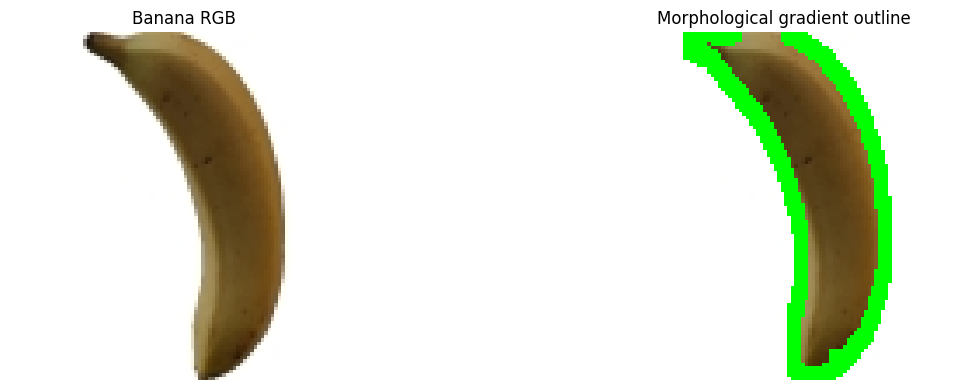

The morphological gradient extracts the banana outline. The green overlay shows the boundary region clearly.


In [8]:
gradient_mask = cv2.morphologyEx(raw_mask, cv2.MORPH_GRADIENT, kernel)
outline = banana_rgb.copy()
outline[gradient_mask == 255] = [0, 255, 0]

show_row(
    ['Banana RGB', 'Morphological gradient outline'],
    [banana_rgb, outline],
    [None, None],
    figsize=(14,4)
)
print('The morphological gradient extracts the banana outline. The green overlay shows the boundary region clearly.')


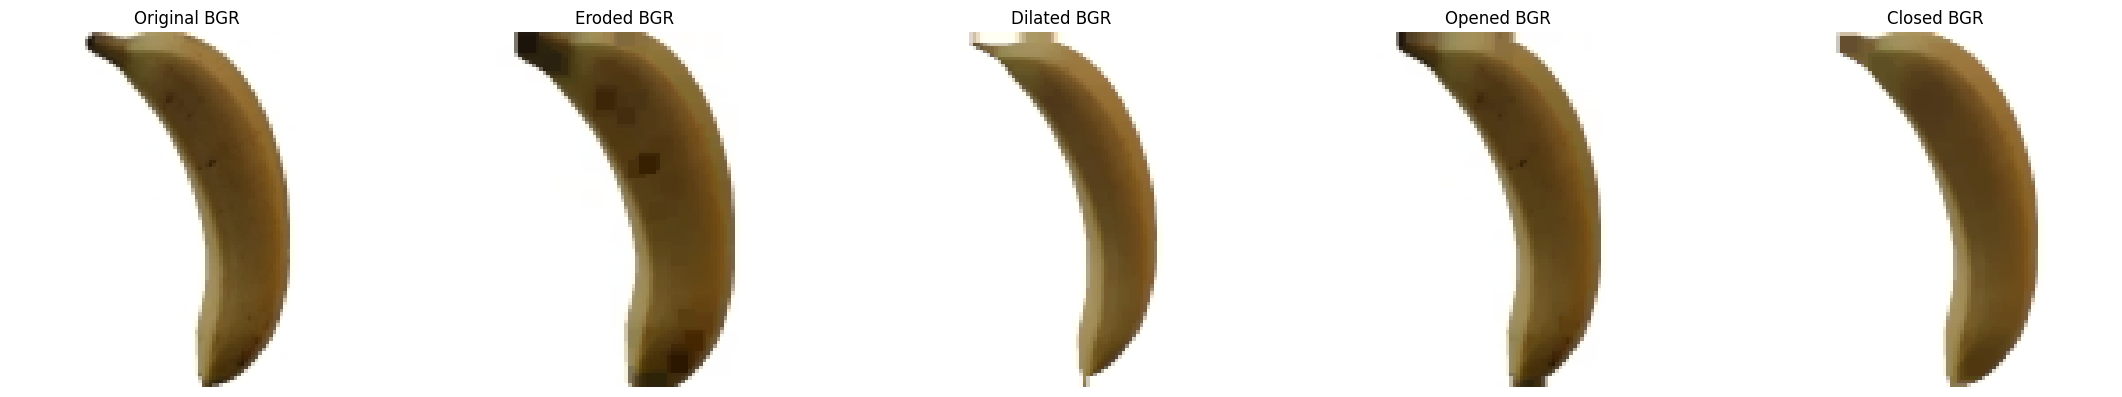

Applying morphology directly to the BGR image distorts colors and smears regions, rather than cleaning a binary mask.


In [9]:
banana_eroded = cv2.erode(banana_bgr, kernel, iterations=1)
banana_dilated = cv2.dilate(banana_bgr, kernel, iterations=1)
banana_opened = cv2.morphologyEx(banana_bgr, cv2.MORPH_OPEN, kernel)
banana_closed = cv2.morphologyEx(banana_bgr, cv2.MORPH_CLOSE, kernel)

show_row(
    ['Original BGR', 'Eroded BGR', 'Dilated BGR', 'Opened BGR', 'Closed BGR'],
    [banana_rgb, cv2.cvtColor(banana_eroded, cv2.COLOR_BGR2RGB), cv2.cvtColor(banana_dilated, cv2.COLOR_BGR2RGB), cv2.cvtColor(banana_opened, cv2.COLOR_BGR2RGB), cv2.cvtColor(banana_closed, cv2.COLOR_BGR2RGB)],
    [None] * 5,
    figsize=(22,4)
)
print('Applying morphology directly to the BGR image distorts colors and smears regions, rather than cleaning a binary mask.')


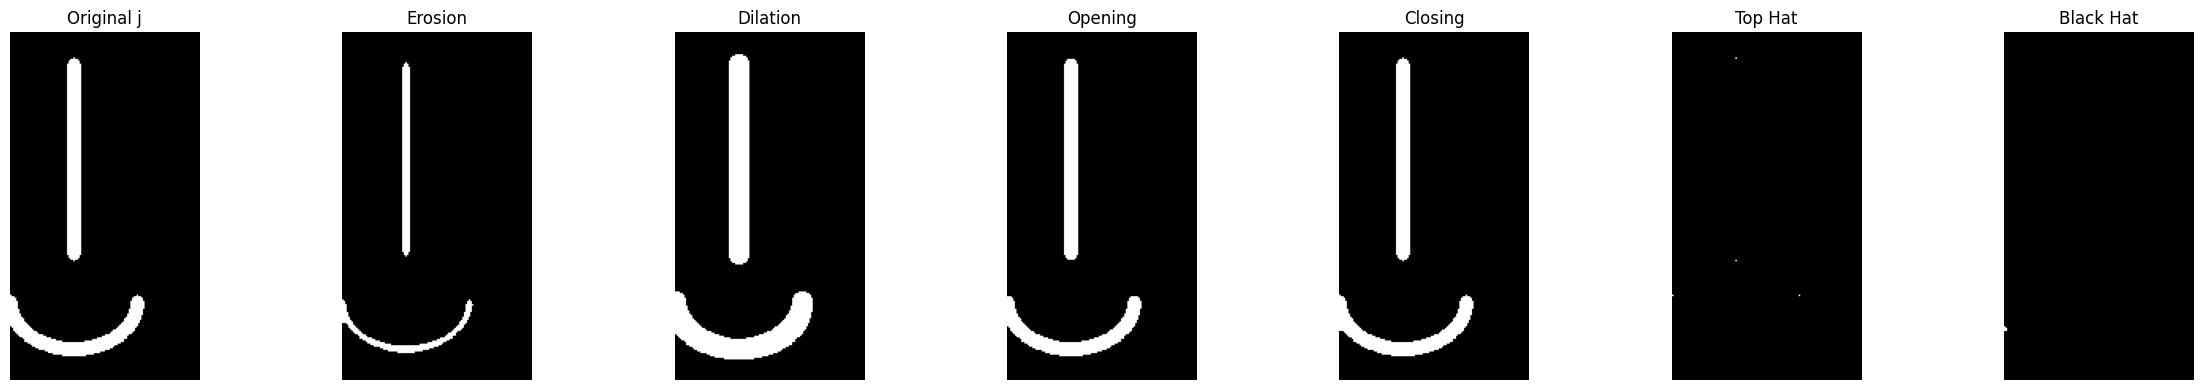

Top Hat isolates bright thin strokes; Black Hat isolates dark background detail around bright strokes.


In [10]:
j_path = os.path.join(base, 'j.png')
if os.path.exists(j_path):
    j_img = cv2.imread(j_path, cv2.IMREAD_GRAYSCALE)
else:
    j_img = np.zeros((220,120), dtype=np.uint8)
    cv2.line(j_img, (40, 20), (40, 140), 255, 8)
    cv2.ellipse(j_img, (40, 170), (40, 30), 0, 0, 180, 255, 8)
    cv2.imwrite(j_path, j_img)
    print('j.png not found; generated a synthetic thin-stroke demo image and saved it to images/j.png.')

j_eroded = cv2.erode(j_img, kernel, iterations=1)
j_dilated = cv2.dilate(j_img, kernel, iterations=1)
j_opened = cv2.morphologyEx(j_img, cv2.MORPH_OPEN, kernel)
j_closed = cv2.morphologyEx(j_img, cv2.MORPH_CLOSE, kernel)
j_tophat = cv2.morphologyEx(j_img, cv2.MORPH_TOPHAT, kernel)
j_blackhat = cv2.morphologyEx(j_img, cv2.MORPH_BLACKHAT, kernel)

show_row(
    ['Original j', 'Erosion', 'Dilation', 'Opening', 'Closing', 'Top Hat', 'Black Hat'],
    [j_img, j_eroded, j_dilated, j_opened, j_closed, j_tophat, j_blackhat],
    ['gray'] * 7,
    figsize=(24,4)
)
print('Top Hat isolates bright thin strokes; Black Hat isolates dark background detail around bright strokes.')
